In [3]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
sns.set_theme(style="whitegrid", palette="deep")

In [5]:
DATA_DIR = next(
    file.parent
    for file in Path("/kaggle/input/datasets/helinatefera/freight-rate").rglob("train-test.csv")
)

In [6]:
train = pd.read_csv(DATA_DIR / "train-test.csv")
validation = pd.read_csv(DATA_DIR / "validation.csv")

In [10]:
# train.head()
validation.head()

,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal
0,TE-000001,Baton Rouge,Mobile,30.50134,-92.65374,31.80442,-88.25195,331.4,Flatbed,19958.0,2025-11-01,0.90402,1.86388
1,TE-000002,Savannah,Los Angeles,33.60973,-82.29994,28.56624,-116.70249,2406.2,Reefer,34114.0,2025-11-01,0.92851,1.86240
2,TE-000003,San Francisco,Raleigh,35.19670,-121.69849,35.37376,-77.47605,2846.6,Dry Van,33435.0,2025-11-01,0.88117,1.95480
3,TE-000004,Dayton,Los Angeles,39.87206,-85.62931,28.56624,-116.70249,2261.6,Dry Van,25392.0,2025-11-01,0.89156,2.14579
4,TE-000005,Memphis,San Antonio,35.56802,-89.52871,29.50969,-98.40059,800.4,Flatbed,NaN,2025-11-01,0.88308,2.22541


In [11]:
train["date"] = pd.to_datetime(train["date"])
validation["date"] = pd.to_datetime(validation["date"])

In [12]:
print("Training shape:", train.shape)
print("Validation shape:", validation.shape)
train.head()

Training shape: (48000, 14)
Validation shape: (12000, 13)


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
0,TR-000001,Richmond,Baltimore,38.09122,-76.78906,38.16908,-72.74564,274.3,Dry Van,30658.0,2025-01-01,0.95684,2.39595,645.41
1,TR-000002,Richmond,Philadelphia,38.09122,-76.78906,39.22317,-72.96710,280.5,Reefer,17555.0,2025-01-01,0.97623,2.43355,679.97
2,TR-000003,Philadelphia,Green Bay,39.22317,-72.96710,44.30296,-87.52871,967.8,Dry Van,31721.0,2025-01-01,1.00971,1.84491,1802.54
3,TR-000004,Hartford,Atlanta,39.55328,-72.18051,34.84933,-86.28940,965.4,Dry Van,32333.0,2025-01-01,0.94518,1.87712,1827.28
4,TR-000005,Dallas,Nashville,31.83025,-94.38343,35.29479,-88.08915,541.9,Reefer,35183.0,2025-01-01,0.98480,2.56300,1380.28


## Check missing values and data quality

In [13]:
def quality_summary(df, name):
    print(f"\n{name}")
    print("=" * 60)
    print("Shape:", df.shape)
    print("Duplicate rows:", df.duplicated().sum())

    summary = pd.DataFrame({
        "missing_count": df.isna().sum(),
        "missing_percent": df.isna().mean() * 100,
        "dtype": df.dtypes.astype(str)
    })

    display(summary)

    numeric_columns = df.select_dtypes(include=np.number).columns

    invalid = pd.DataFrame(index=numeric_columns)
    invalid["negative_values"] = [
        (df[column] < 0).sum()
        for column in numeric_columns
    ]
    invalid["zero_values"] = [
        (df[column] == 0).sum()
        for column in numeric_columns
    ]

    display(invalid)

quality_summary(train, "Training Data")
quality_summary(validation, "Validation Data")


Training Data
Shape: (48000, 14)
Duplicate rows: 0


,missing_count,missing_percent,dtype
load_id,0,0.000000,object
pickup,0,0.000000,object
delivery,0,0.000000,object
pickup_lat,0,0.000000,float64
pickup_lon,0,0.000000,float64
delivery_lat,0,0.000000,float64
delivery_lon,0,0.000000,float64
distance,0,0.000000,float64
equipment,0,0.000000,object
weight,300,0.625000,float64


,negative_values,zero_values
pickup_lat,0,0
pickup_lon,48000,0
delivery_lat,0,0
delivery_lon,48000,0
distance,0,0
weight,292,0
market_index,0,0
quote_signal,0,0
posted_rate,0,0



Validation Data
Shape: (12000, 13)
Duplicate rows: 0


,missing_count,missing_percent,dtype
load_id,0,0.000,object
pickup,0,0.000,object
delivery,0,0.000,object
pickup_lat,0,0.000,float64
pickup_lon,0,0.000,float64
delivery_lat,0,0.000,float64
delivery_lon,0,0.000,float64
distance,0,0.000,float64
equipment,0,0.000,object
weight,165,1.375,float64


,negative_values,zero_values
pickup_lat,0,0
pickup_lon,12000,0
delivery_lat,0,0
delivery_lon,12000,0
distance,0,0
weight,145,0
market_index,0,0
quote_signal,0,0


## Visualize missing values

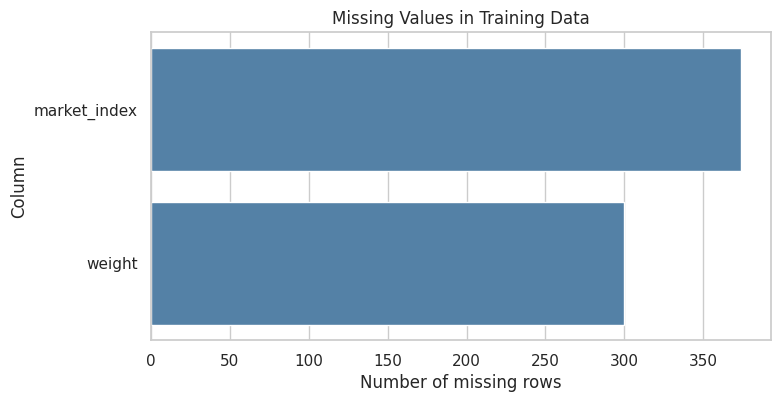

In [14]:
missing = train.isna().sum()
missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(
    x=missing.values,
    y=missing.index,
    color="steelblue"
)
plt.title("Missing Values in Training Data")
plt.xlabel("Number of missing rows")
plt.ylabel("Column")
plt.show()

## Visualize numeric distributions

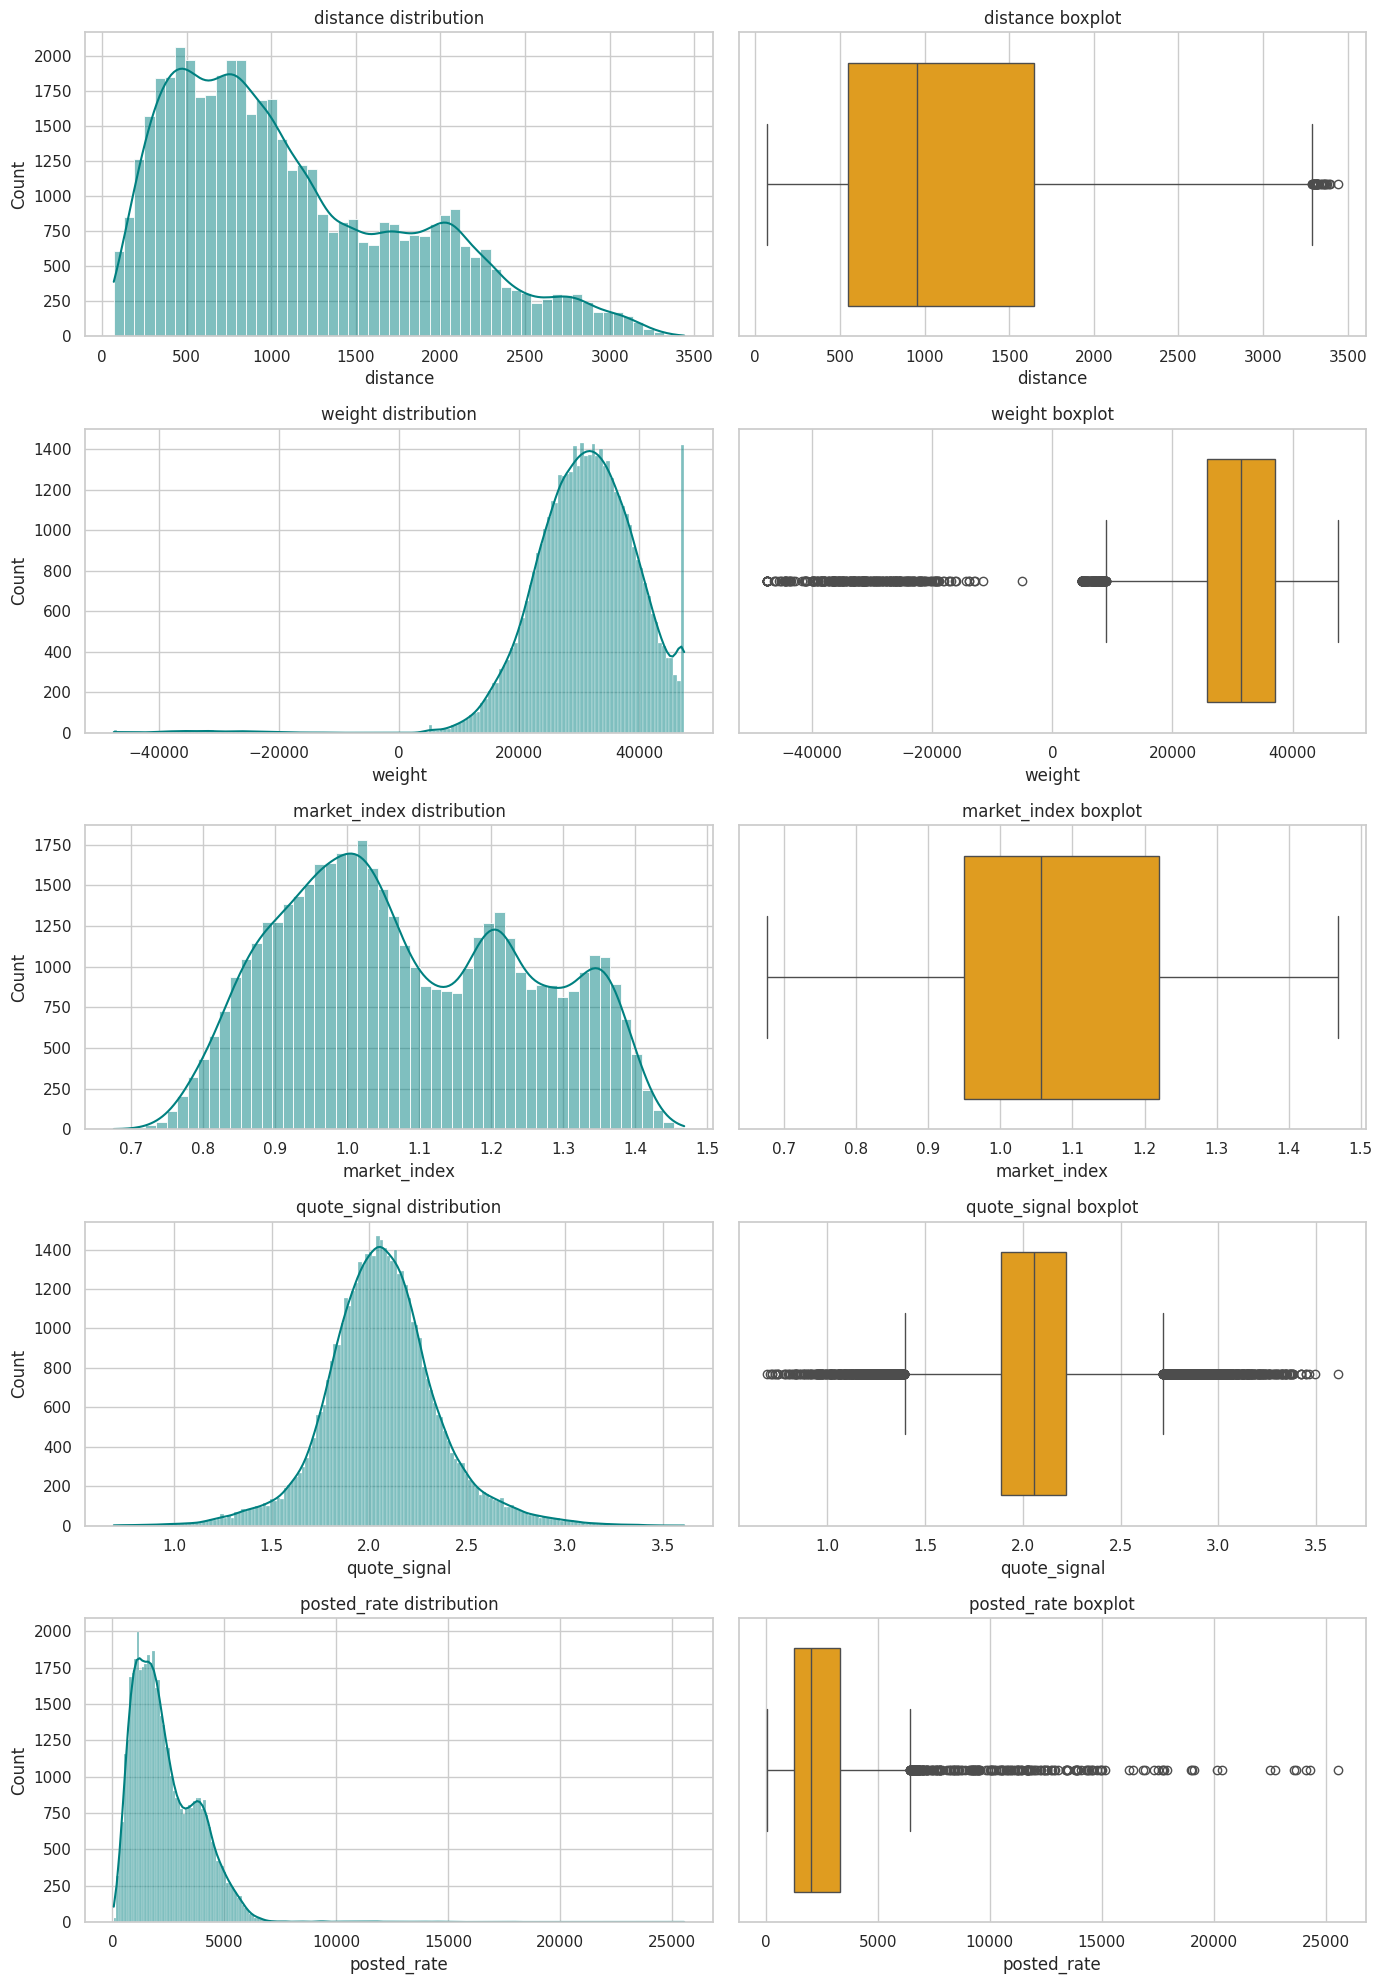

In [15]:
numeric_columns = [
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate"
]

fig, axes = plt.subplots(
    len(numeric_columns),
    2,
    figsize=(14, 20)
)

for row, column in enumerate(numeric_columns):
    sns.histplot(
        data=train,
        x=column,
        kde=True,
        ax=axes[row, 0],
        color="teal"
    )
    axes[row, 0].set_title(f"{column} distribution")

    sns.boxplot(
        data=train,
        x=column,
        ax=axes[row, 1],
        color="orange"
    )
    axes[row, 1].set_title(f"{column} boxplot")

plt.tight_layout()
plt.show()

## Dataset Overview

The development dataset contains 48,000 rows and 14 columns. It includes load information such as pickup and delivery locations, geographic coordinates, distance, equipment type, weight, date, market indicators, quote signals, and the target variable `posted_rate`.

The validation dataset contains 12,000 rows and 13 columns. It contains the same input features but does not include `posted_rate`, because these are the loads requiring final predictions.

No duplicate rows were found in either dataset.

## Key Findings

The data contains both categorical and numerical features. The categorical features are `pickup`, `delivery`, and `equipment`. The numerical features include geographic coordinates, distance, weight, market index, and quote signal.

The `date` column is already available in datetime format, which makes it suitable for creating additional time-based features such as month, day, weekday, and season.

The dataset contains a small number of missing values. Missing values are concentrated in:

* `weight`
* `market_index`

The training data contains 300 missing weight values, representing 0.625% of the data, and 374 missing market index values, representing 0.779% of the data.

The validation data contains 165 missing weight values, representing 1.375% of the data, and 249 missing market index values, representing 2.075% of the data.

The longitude values are negative for all records. This is not a data quality problem because negative longitude values correctly represent locations in the western hemisphere. Therefore, these values should be retained.

## Data Quality Issues

The main data quality issue is the presence of negative values in the `weight` column:

* Training data: 292 negative values
* Validation data: 145 negative values

A negative freight weight is not physically meaningful, so these values were treated as invalid. They were converted to missing values before imputation.

No invalid negative values were found in `distance`, `market_index`, or `quote_signal`. There were also no missing values in the location, equipment, distance, date, or quote signal columns.

## Cleaning Decisions

The following cleaning approach will be used:

1. Keep `load_id` as an identifier and exclude it from model features.
2. Convert the `date` column to datetime format.
3. Remove unnecessary spaces from categorical text values.
4. Convert negative `weight` values to missing values.
5. Impute missing numerical values using the median calculated from the training data.
6. Apply the same training data medians to the validation data to prevent data leakage.
7. Keep negative longitude values because they are valid geographic coordinates.
8. Keep all rows because the missing and invalid values can be handled without losing training examples.
9. Create date based features such as month, day of week, and day of month.
10. Encode categorical features such as pickup, delivery, and equipment for modeling.

This approach preserves the available information, avoids unnecessary row removal, and ensures that the validation data is processed using rules learned only from the training data.


## Check negative weights directly

Negative training weights: 292


,load_id,pickup,delivery,pickup_lat,pickup_lon,delivery_lat,delivery_lon,distance,equipment,weight,date,market_index,quote_signal,posted_rate
68,TR-000069,Amarillo,Dayton,33.17137,-104.36789,39.87206,-85.62931,1334.2,Reefer,-36559.0,2025-01-01,0.96102,2.11777,2831.27
204,TR-000205,Fresno,Tucson,33.07921,-119.79528,30.92733,-113.23037,496.2,Dry Van,-26670.0,2025-01-02,0.96903,2.13155,1046.92
206,TR-000207,Columbia,Raleigh,34.63570,-83.28506,35.37376,-77.47605,411.3,Reefer,-20003.0,2025-01-02,0.94800,2.31682,959.15
225,TR-000226,Greensboro,Lubbock,35.98195,-82.78379,29.87534,-99.85456,1317.4,Reefer,-23981.0,2025-01-02,1.00820,2.13918,2836.00
376,TR-000377,Madison,Providence,41.70243,-89.85588,37.37287,-69.50000,1331.1,Dry Van,-41397.0,2025-01-03,0.94787,1.91867,2522.54


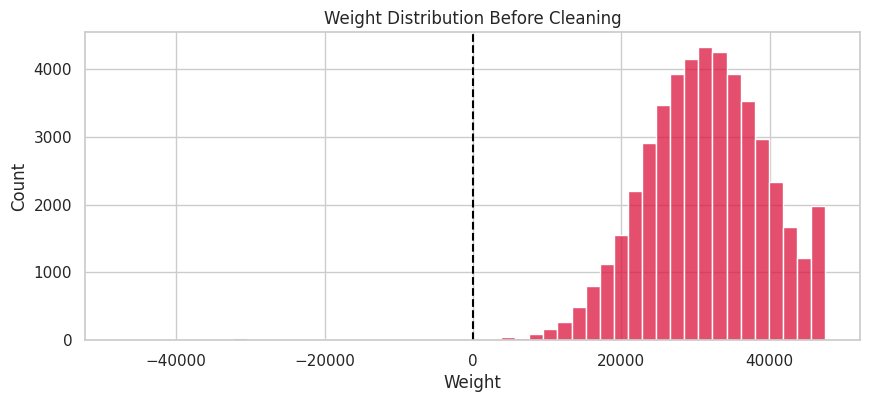

In [16]:
negative_weight = train[train["weight"] < 0]

print("Negative training weights:", len(negative_weight))
display(negative_weight.head())

plt.figure(figsize=(10, 4))
sns.histplot(
    data=train,
    x="weight",
    bins=50,
    color="crimson"
)
plt.axvline(0, color="black", linestyle="--")
plt.title("Weight Distribution Before Cleaning")
plt.xlabel("Weight")
plt.show()

## Explore categorical features

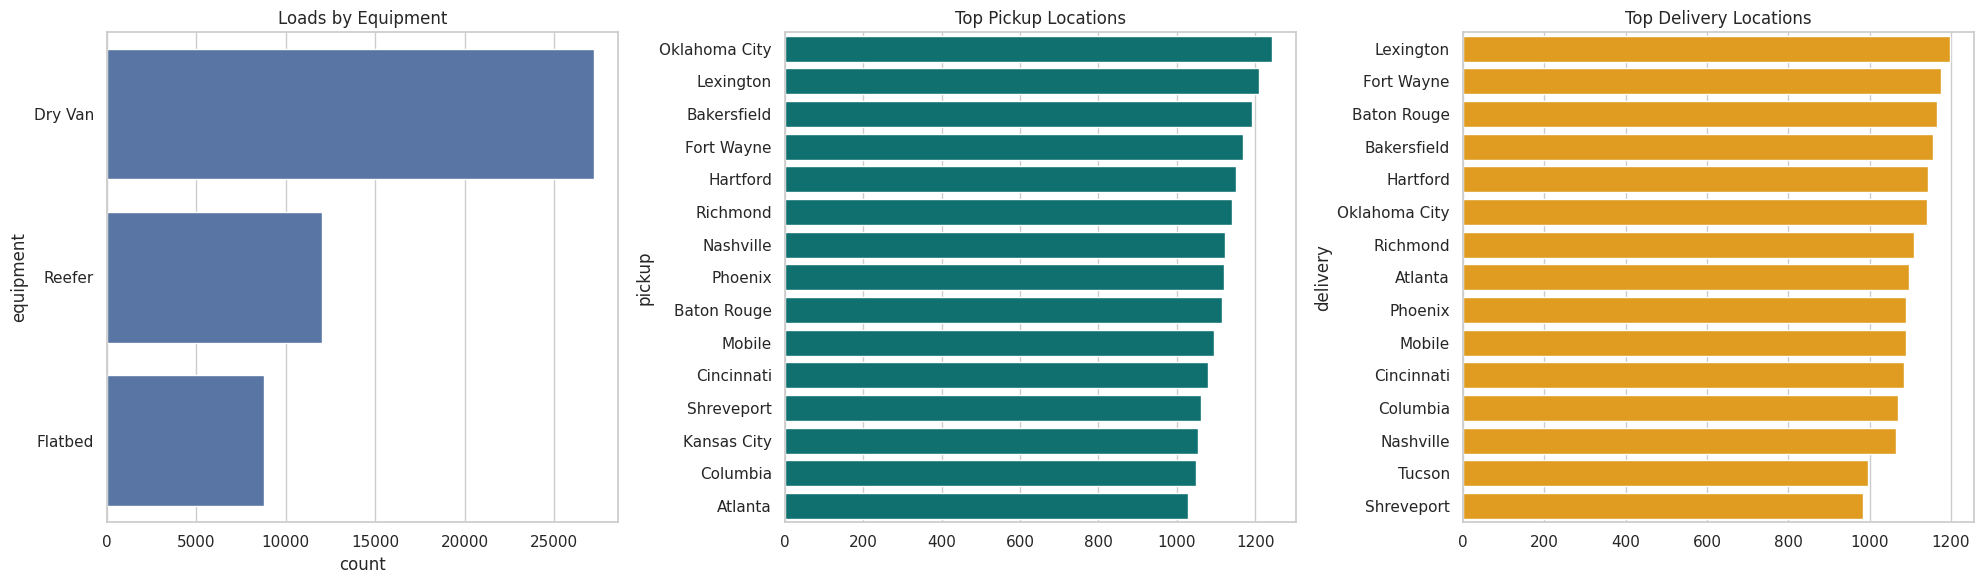

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.countplot(
    data=train,
    y="equipment",
    order=train["equipment"].value_counts().index,
    ax=axes[0]
)
axes[0].set_title("Loads by Equipment")

top_pickups = train["pickup"].value_counts().head(15)
sns.barplot(
    x=top_pickups.values,
    y=top_pickups.index,
    ax=axes[1],
    color="teal"
)
axes[1].set_title("Top Pickup Locations")

top_deliveries = train["delivery"].value_counts().head(15)
sns.barplot(
    x=top_deliveries.values,
    y=top_deliveries.index,
    ax=axes[2],
    color="orange"
)
axes[2].set_title("Top Delivery Locations")

plt.tight_layout()
plt.show()

## Categorical Feature Exploration

The categorical feature analysis focused on equipment type, pickup location, and delivery location.

Dry Van is the most common equipment type, with 27,202 loads, representing approximately 56.7% of the training data. Reefer accounts for 12,045 loads, or 25.1%, while Flatbed accounts for 8,753 loads, or 18.2%. This shows that Dry Van loads are the dominant category, but the other equipment types also provide enough examples for the model to learn from.

The pickup and delivery charts show that loads are distributed across many locations rather than being concentrated in one single city. The most common pickup locations include Oklahoma City, Lexington, Bakersfield, Fort Wayne, Hartford, and Richmond. The most common delivery locations include Lexington, Fort Wayne, Baton Rouge, Bakersfield, Hartford, and Oklahoma City.

Pickup and delivery frequencies are relatively similar across the main locations. This suggests that location is an important feature, but the model should use pickup and delivery together as a route rather than relying on either location independently.

For modeling, I will retain the equipment, pickup, and delivery features. These categorical variables can capture differences in vehicle type, origin, destination, and route pricing. They will be encoded using a method that can handle locations appearing in the validation data but not in the training data.


## Explore the target by equipment

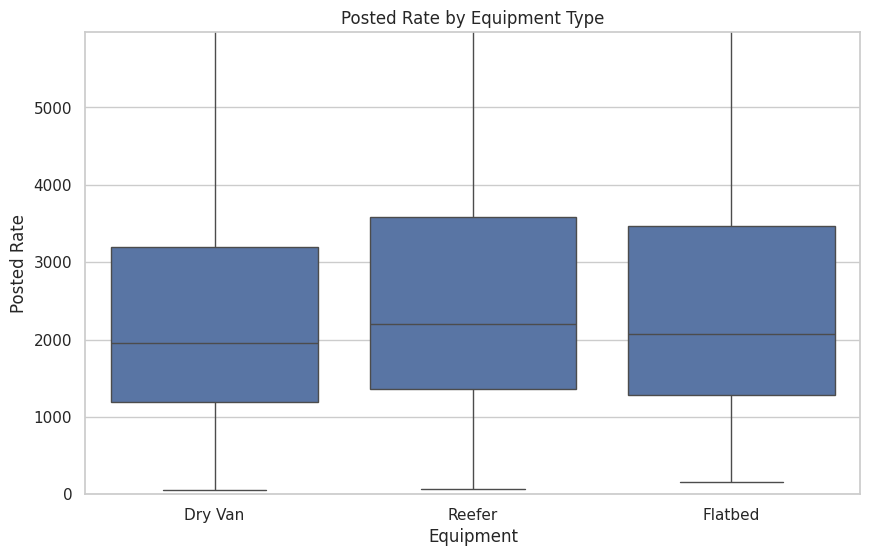

In [18]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=train,
    x="equipment",
    y="posted_rate"
)

plt.title("Posted Rate by Equipment Type")
plt.xlabel("Equipment")
plt.ylabel("Posted Rate")
plt.ylim(0, train["posted_rate"].quantile(0.99))
plt.show()

The target variable `posted_rate` was compared across the three equipment types: Dry Van, Reefer, and Flatbed.

Reefer loads have the highest average and median rates. The average Reefer rate is approximately $2,553.64, with a median of $2,196.67. Flatbed loads have an average rate of $2,445.09 and a median of $2,076.81. Dry Van loads have the lowest average rate at approximately $2,271.55, with a median of $1,953.04.

| Equipment | Number of Loads | Average Rate | Median Rate |
| --------- | --------------: | -----------: | ----------: |
| Dry Van   |          27,202 |    $2,271.55 |   $1,953.04 |
| Flatbed   |           8,753 |    $2,445.09 |   $2,076.81 |
| Reefer    |          12,045 |    $2,553.64 |   $2,196.67 |

The boxplot also shows that all equipment categories have a wide range of rates and several high value outliers. The distributions are right skewed, meaning that most loads have moderate rates but a smaller number of loads have much higher rates.

This analysis suggests that equipment type provides useful information for predicting freight rates. However, equipment alone does not explain the full variation in the target. Other features, especially distance, route, weight, and market conditions, should also be included in the model. I will keep `equipment` as a categorical feature and allow the model to learn its relationship with the target.


## Explore distance and freight rate

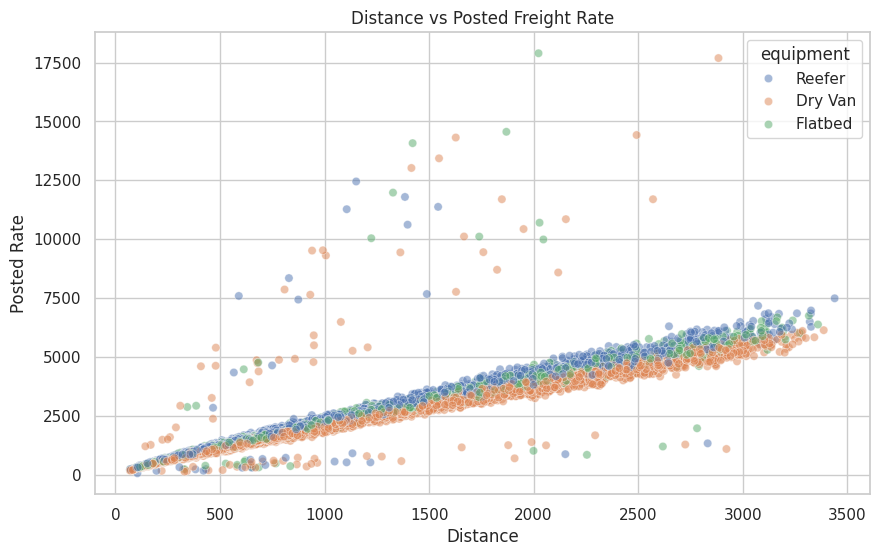

In [19]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=train.sample(min(10000, len(train)), random_state=42),
    x="distance",
    y="posted_rate",
    hue="equipment",
    alpha=0.5
)

plt.title("Distance vs Posted Freight Rate")
plt.xlabel("Distance")
plt.ylabel("Posted Rate")
plt.show()

The relationship between `distance` and `posted_rate` was analyzed using a scatter plot.

The correlation between distance and posted rate is approximately **0.91**, showing a strong positive relationship. In general, longer routes have higher freight rates.

The average rate increases consistently across distance groups:

| Distance Group         | Average Posted Rate |
| ---------------------- | ------------------: |
| Shortest routes        |             $796.12 |
| Short to medium routes |           $1,437.59 |
| Medium routes          |           $2,073.43 |
| Medium to long routes  |           $3,045.22 |
| Longest routes         |           $4,517.88 |

The scatter plot also shows some variation and high value outliers. This means distance is a very important predictor, but it cannot explain every rate by itself. Equipment type, route, weight, market index, quote signal, and date may explain the remaining differences.

I will keep `distance` as a numerical feature and include it directly in the model. I will also test whether transformations or additional features, such as rate per mile or distance groups, improve model performance.


## Explore correlations

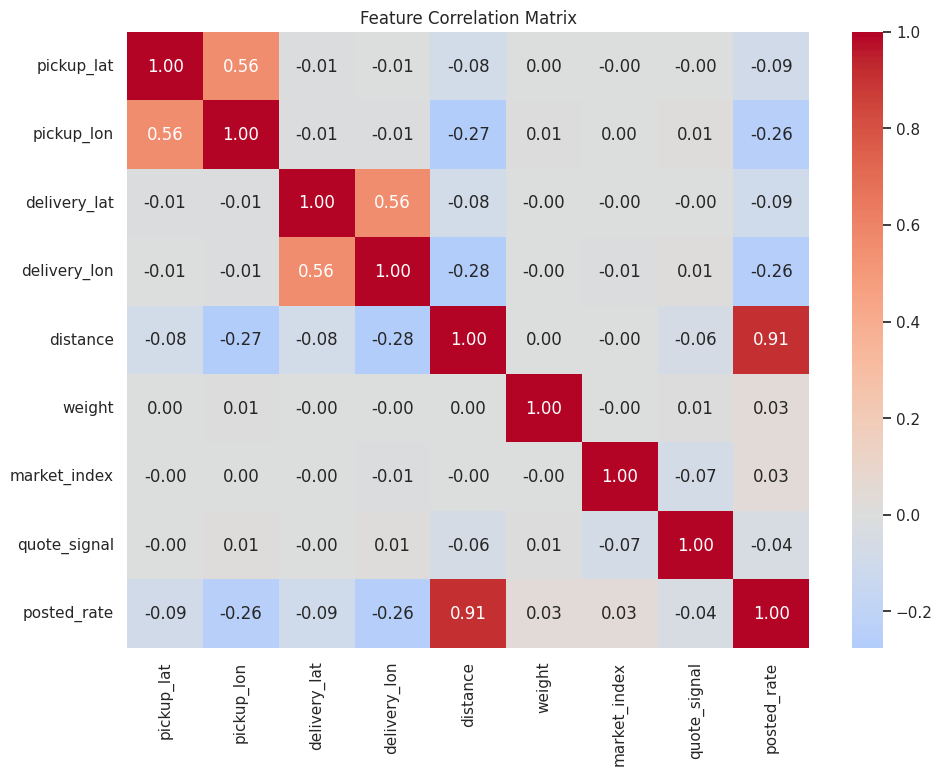

In [20]:
correlation_columns = [
    "pickup_lat",
    "pickup_lon",
    "delivery_lat",
    "delivery_lon",
    "distance",
    "weight",
    "market_index",
    "quote_signal",
    "posted_rate"
]

plt.figure(figsize=(11, 8))

correlation_matrix = train[correlation_columns].corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Feature Correlation Matrix")
plt.show()

The correlation heatmap was used to examine relationships between the numerical features and the target variable `posted_rate`.

The strongest relationship is between `distance` and `posted_rate`, with a correlation of approximately **0.91**. This confirms that distance is likely the most influential numerical feature for predicting freight rates.

The geographic longitude features have moderate negative relationships with the target:

* `pickup_lon`: approximately **-0.26**
* `delivery_lon`: approximately **-0.26**

The latitude features have weaker relationships with the target, around **-0.09**.

The remaining numerical variables have relatively weak linear correlations with the target:

* `weight`: approximately **0.04**
* `market_index`: approximately **0.03**
* `quote_signal`: approximately **-0.04**

The pickup and delivery latitude and longitude features are moderately correlated with each other because they describe geographic locations. This is expected and does not necessarily mean that one of them should be removed.

The low correlation of weight, market index, and quote signal does not mean that these features are useless. Their effect may be nonlinear or dependent on route, equipment, and date. I will keep these features and allow the machine learning model to determine their value.

Based on this analysis, distance, route information, equipment type, and geographic features will be important parts of the prediction model. However, correlation alone will not be used to remove features.


## Explore time patterns

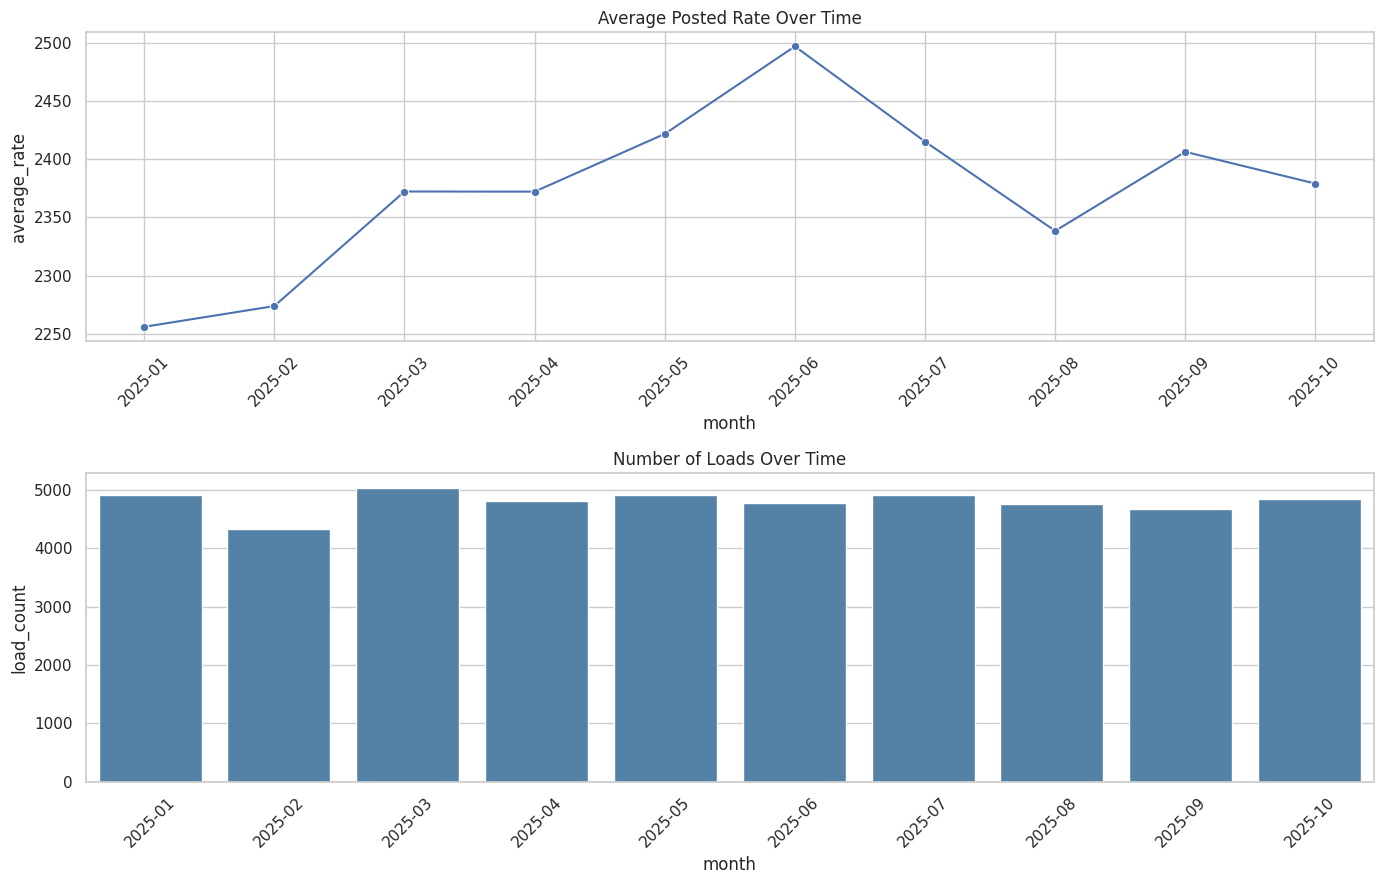

In [21]:
monthly = (
    train.assign(month=train["date"].dt.to_period("M").astype(str))
    .groupby("month")
    .agg(
        average_rate=("posted_rate", "mean"),
        median_rate=("posted_rate", "median"),
        load_count=("posted_rate", "size")
    )
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(14, 9))

sns.lineplot(
    data=monthly,
    x="month",
    y="average_rate",
    marker="o",
    ax=axes[0]
)
axes[0].set_title("Average Posted Rate Over Time")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=monthly,
    x="month",
    y="load_count",
    ax=axes[1],
    color="steelblue"
)
axes[1].set_title("Number of Loads Over Time")
axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

The training data covers January through October 2025. The number of loads is relatively consistent across the months, although February has the lowest number of records.

The average posted rate increases from January through June:

* January: $2,255.97
* February: $2,273.80
* March: $2,372.27
* April: $2,372.16
* May: $2,421.78
* June: $2,497.03

The average rate reaches its highest point in June. It then decreases in July and August, reaching approximately $2,338.41 in August. The average rate increases again in September and remains relatively stable in October.

This shows that freight rates may change over time. Since the validation data represents future months, time should be considered during validation. I will create features such as month, day of week, and day of month. I will also consider using a chronological validation split so that the evaluation better represents the real prediction task.

The date feature will be retained because it may capture seasonal demand and changes in market conditions.

In [22]:
route_count = train.groupby(
    ["pickup", "delivery"]
).size()

distance_corr = train[
    ["distance", "posted_rate"]
].corr().loc["distance", "posted_rate"]

print("KEY FINDINGS")
print("=" * 60)
print(f"Training rows: {len(train):,}")
print(f"Validation rows: {len(validation):,}")
print(f"Unique equipment types: {train['equipment'].nunique()}")
print(f"Unique pickup locations: {train['pickup'].nunique()}")
print(f"Unique delivery locations: {train['delivery'].nunique()}")
print(f"Unique pickup-delivery routes: {route_count.size:,}")
print(f"Distance/rate correlation: {distance_corr:.3f}")
print(f"Missing weight values: {train['weight'].isna().sum():,}")
print(f"Missing market index values: {train['market_index'].isna().sum():,}")
print(f"Negative weight values: {(train['weight'] < 0).sum():,}")
print(f"Duplicate rows: {train.duplicated().sum():,}")

new_pickups = set(validation["pickup"]) - set(train["pickup"])
new_deliveries = set(validation["delivery"]) - set(train["delivery"])

print(f"New validation pickup locations: {len(new_pickups)}")
print(f"New validation delivery locations: {len(new_deliveries)}")

KEY FINDINGS
Training rows: 48,000
Validation rows: 12,000
Unique equipment types: 3
Unique pickup locations: 64
Unique delivery locations: 64
Unique pickup-delivery routes: 4,014
Distance/rate correlation: 0.909
Missing weight values: 300
Missing market index values: 374
Negative weight values: 292
Duplicate rows: 0
New validation pickup locations: 8
New validation delivery locations: 8
